# 离散贝叶斯网络 vs 高斯贝叶斯网络

贝叶斯网络根据变量类型的不同，可以分为：

- **离散贝叶斯网络（Discrete Bayesian Network）**
- **高斯贝叶斯网络（Gaussian Bayesian Network）**

两者的核心区别在于：

> 如何表示变量之间的概率关系。

---

# 1. 离散贝叶斯网络（Discrete Bayesian Network）

## 1.1 基本思想

离散贝叶斯网络要求网络中的变量取有限个离散状态。


例如：

原始变量：平均半径

经过离散化后：小 / 中 / 大


因此变量取值：

\[
X_i \in \{0,1,2\}
\]


其中：

- 0：小
- 1：中
- 2：大


---

## 1.2 概率表示方式

离散贝叶斯网络通过：

**CPT（Conditional Probability Table，条件概率表）**

描述节点与父节点之间的概率关系。


数学表示：

\[
P(X_i|Parents(X_i))
\]


例如：

网络结构：
   诊断结果
       |
       ↓
   平均半径
   

需要学习：

\[
P(平均半径|诊断结果)
\]


对应的条件概率表：

|诊断结果|小半径|中半径|大半径|
|-|-|-|-|
|恶性|0.05|0.25|0.70|
|良性|0.70|0.25|0.05|


解释：

当诊断结果为恶性时：

- 半径大的概率为：

\[
P(大半径|恶性)=0.70
\]


- 半径小的概率为：

\[
P(小半径|恶性)=0.05
\]


通过这些概率表，可以完成：

\[
P(诊断结果|特征)
\]


即根据观察到的特征推断类别。

---

# 2. 高斯贝叶斯网络（Gaussian Bayesian Network）

## 2.1 基本思想

高斯贝叶斯网络用于描述连续变量。


变量保持原始连续形式：

例如：
平均半径

17.3

20.5

13.2


不需要转换为：
小

中

大


---

## 2.2 概率表示方式

高斯贝叶斯网络假设：

变量在给定父节点条件下服从高斯分布。


即：

\[
X_i|Parents(X_i)
\sim N(\mu,\sigma^2)
\]


其中：

- \(\mu\)：均值
- \(\sigma^2\)：方差


例如：

对于：

\[
P(平均半径|诊断结果)
\]


模型学习的是：

一个连续概率分布：

\[
N(\mu,\sigma^2)
\]


而不是概率表。

---

# 3. 高斯贝叶斯网络中的参数学习

高斯贝叶斯网络学习：

## （1）均值

\[
\mu
\]


表示变量的中心位置。

---

## （2）方差

\[
\sigma^2
\]


表示数据波动程度。


---

## （3）回归系数

当变量之间存在依赖关系时：

例如：
平均半径
↓
平均周长
↓
平均面积


变量关系可以表示为：

[平均周长=
\beta_0+
\beta_1\times平均半径
+\epsilon
\]


其中：

\[
\epsilon\sim N(0,\sigma^2)
\]


表示随机误差。


---

# 4. 两种贝叶斯网络的核心区别


| |离散贝叶斯网络|高斯贝叶斯网络|
|-|-|-|
|变量类型|离散变量|连续变量|
|数据形式|类别、状态|测量值|
|是否需要离散化|需要|不需要|
|概率表示|CPT条件概率表|高斯分布|
|学习参数|概率值|均值、方差、回归系数|
|典型变量|小/中/大|17.3、20.5、13.2|
|适合数据|文本、类别数据|医学指标、传感器数据|

---

# 5. 与朴素贝叶斯的关系


## Gaussian Naive Bayes

实际上是：

一种特殊的高斯贝叶斯网络。


结构：
      类别C

  /    |    \

 X1    X2    X3
 

假设：

所有特征条件独立：


\[
P(X_1,X_2,X_3|C)=
P(X_1|C)
P(X_2|C)
P(X_3|C)
\]


---

## 高斯贝叶斯网络


允许：

特征之间存在依赖。


例如：
    诊断结果

        ↓

    平均半径

        ↓

    平均周长

        ↓

    平均面积
    

此时：

\[
P(面积|周长)
\]


可以被建模。


因此：

高斯贝叶斯网络比GaussianNB具有更强的表达能力。

---

# 6. 为什么实验中使用离散贝叶斯网络？

虽然乳腺癌数据本质是连续数据：

例如：

- 半径
- 面积
- 周长


但是离散贝叶斯网络具有：

## 优点

1. CPT直观

可以直接观察：

\[
P(大半径|恶性)
\]


2. 容易展示网络推断过程

3. 适合理解：

- DAG结构
- 条件独立
- 概率推理


---

## 缺点

需要离散化：

连续信息会损失。


例如：

原始：
17.3
17.8
18.2

可能变成：
大
大
大


导致细节丢失。


---


1.加载数据

In [1]:
from sklearn.datasets import load_breast_cancer

import pandas as pd
import numpy as np


data = load_breast_cancer()


X = data.data
y = data.target


print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [8]:
features_cn = {

    "mean radius":"平均半径",

    "mean texture":"平均纹理",

    "mean perimeter":"平均周长",

    "mean area":"平均面积",

    "mean smoothness":"平均平滑度"

}


X_selected = pd.DataFrame(

    X[:,[
        0,
        1,
        2,
        3,
        4
    ]],

    columns=list(features_cn.values())

)


X_selected["诊断结果"]=y


X_selected.head(20)


,平均半径,平均纹理,平均周长,平均面积,平均平滑度,诊断结果
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0
5,12.45,15.70,82.57,477.1,0.12780,0
6,18.25,19.98,119.60,1040.0,0.09463,0
7,13.71,20.83,90.20,577.9,0.11890,0
8,13.00,21.82,87.50,519.8,0.12730,0
9,12.46,24.04,83.97,475.9,0.11860,0


2.分析数据集的相关性热力图。（探索性分析EDA）

In [4]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']  # 黑体
plt.rcParams['axes.unicode_minus'] = False   # 解决负号显示问题

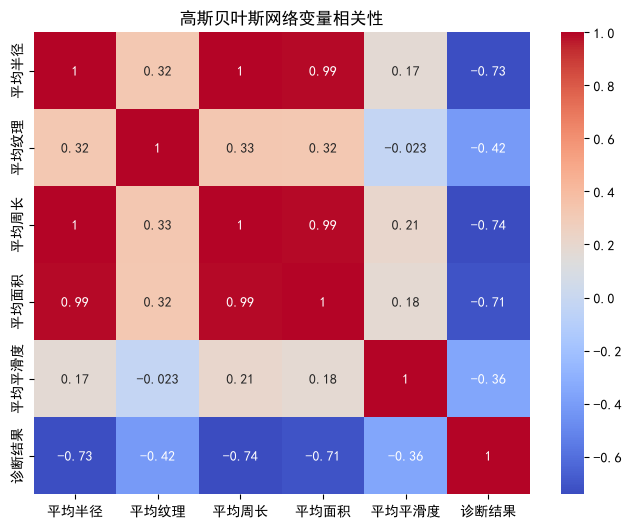

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8,6))


sns.heatmap(

    X_selected.corr(),

    annot=True,

    cmap="coolwarm"

)


plt.title(
    "高斯贝叶斯网络变量相关性"
)


plt.show()

3.数据集划分

In [10]:
from sklearn.model_selection import train_test_split


# 特征
X_data = X_selected.drop(
    columns=["诊断结果"]
)


# 标签
y_data = X_selected["诊断结果"]


X_train, X_test, y_train, y_test = train_test_split(
    X_data,
    y_data,
    test_size=0.2,
    random_state=42,
    stratify=y_data
)


print("训练集大小:", X_train.shape)
print("测试集大小:", X_test.shape)

训练集大小: (455, 5)
测试集大小: (114, 5)


4.设计高斯贝叶斯网格结构(知识驱动或数据驱动)
数据驱动的自动设计方法：
基于评分搜索（随机结构->计算BIC评分->修改边->重新计算->直到最好）————爬山算法
基于约束搜索（比如：检测X⊥Y∣Z如果条件独立就不连接）————PC算法，IC算法
基于混合的方法（评分+独立性）————MMHC
但最优预测结构 ≠ 最合理解释结构，基于专家知识判断的网络结构可能会优于基于数据的网络结构

A.Hill Climbing + BIC 自动学习网络结构

In [11]:
train_data = X_train.copy()

train_data["诊断结果"] = y_train


train_data.head()

,平均半径,平均纹理,平均周长,平均面积,平均平滑度,诊断结果
546,10.32,16.35,65.31,324.9,0.09434,1
432,20.18,19.54,133.80,1250.0,0.11330,0
174,10.66,15.15,67.49,349.6,0.08792,1
221,13.56,13.90,88.59,561.3,0.10510,1
289,11.37,18.89,72.17,396.0,0.08713,1


In [18]:
from pgmpy.estimators import HillClimbSearch
from pgmpy.estimators import BICGauss
#创建高斯评分器
score = BICGauss(
    train_data
)
#Hill Climbing搜索
hc = HillClimbSearch(
    train_data
)


best_model = hc.estimate(
    scoring_method=score,
    max_iter=100
)
best_model.edges()
print("学习到的边数量:")
print(len(best_model.edges()))

print("网络结构:")
for edge in best_model.edges():
    print(edge)

C:\Users\28429\AppData\Local\Temp\ipykernel_28988\1487234089.py:8: FutureWarning: HillClimbSearch is deprecated and will be removed in v1.3.0. Please use
            pgmpy.causal_discovery.HillClimbSearch instead.
  hc = HillClimbSearch(
  9%|▉         | 9/100 [00:00<00:05, 17.43it/s]

学习到的边数量:
9
网络结构:
('平均半径', '平均周长')
('平均半径', '平均面积')
('平均周长', '诊断结果')
('平均面积', '平均平滑度')
('平均面积', '诊断结果')
('平均平滑度', '平均周长')
('平均平滑度', '诊断结果')
('平均平滑度', '平均纹理')
('诊断结果', '平均纹理')


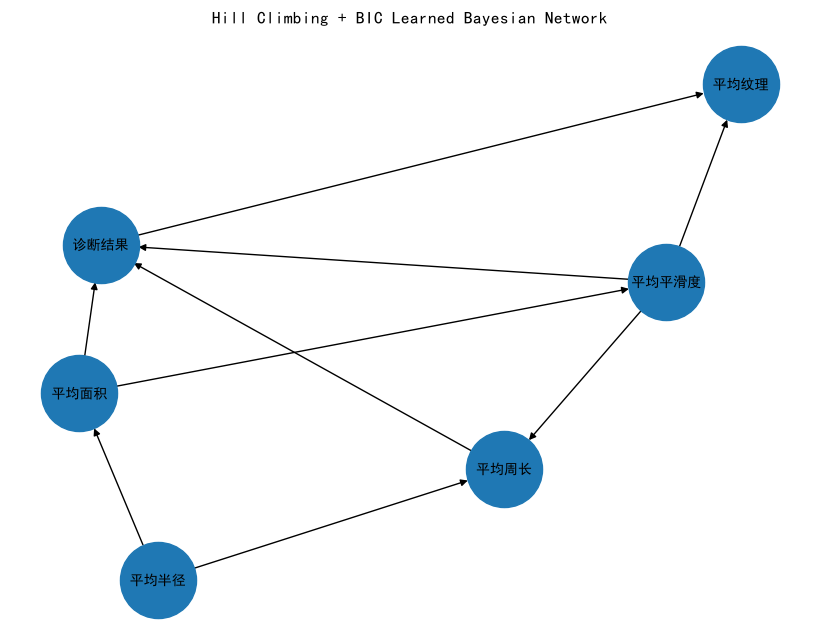

In [19]:
import networkx as nx
import matplotlib.pyplot as plt


plt.figure(figsize=(8,6))


G = nx.DiGraph()


G.add_edges_from(
    best_model.edges()
)


pos = nx.spring_layout(
    G,
    seed=42
)


nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    font_size=10,
    arrows=True
)


plt.title(
    "Hill Climbing + BIC Learned Bayesian Network"
)


plt.show()

In [24]:
print(X_train.columns)

print(list(best_model.nodes()))

Index(['平均半径', '平均纹理', '平均周长', '平均面积', '平均平滑度'], dtype='str')
['平均半径', '平均纹理', '平均周长', '平均面积', '平均平滑度', '诊断结果']


5.参数学习（学习条件概率）

In [25]:
from pgmpy.models import LinearGaussianBayesianNetwork


lg_bn = LinearGaussianBayesianNetwork(
    best_model.edges()
)


lg_bn.fit(
    train_data
)

In [26]:
for cpd in lg_bn.cpds:
    print(cpd)

P(平均半径) = N(14.067; 3.499)
P(平均周长 | 平均半径, 平均平滑度) = N(6.834*平均半径 + 71.901*平均平滑度 + -11.497; 1.296)
P(平均面积 | 平均半径) = N(97.478*平均半径 + -722.696; 51.341)
P(诊断结果 | 平均周长, 平均面积, 平均平滑度) = N(-0.028*平均周长 + 0.001*平均面积 + -7.9*平均平滑度 + 3.324; 0.299)
P(平均平滑度 | 平均面积) = N(0.0*平均面积 + 0.091; 0.013)
P(平均纹理 | 平均平滑度, 诊断结果) = N(-78.04*平均平滑度 + -4.574*诊断结果 + 29.618; 3.91)


6.建立模型并预测（预测出来是连续值，结果不是概率，而是Y∼N(μ,σ2)，所以后续要二元离散转化为分类结果）

In [36]:
X_test_bn = X_test[
    [
        "平均周长",
        "平均面积",
        "平均平滑度"
    ]
]
y_pred_value = lg_bn.predict(
    X_test_bn
)
y_score = y_pred_value["诊断结果"]

print(y_score.head())

256    0.032131
428    1.067373
501    0.392075
363    0.387671
564   -0.072863
Name: 诊断结果, dtype: float64


7.转化为分类结果

In [38]:
y_pred = (
    y_score >=0.5
).astype(int)
print(y_pred.head())

256    0
428    1
501    0
363    0
564    0
Name: 诊断结果, dtype: int64


8.模型评价

In [39]:

from sklearn.metrics import accuracy_score


acc = accuracy_score(
    y_test,
    y_pred
)


print(
    "Linear Gaussian BN准确率:",
    acc
)

Linear Gaussian BN准确率: 0.8947368421052632


9.混淆矩阵

In [40]:
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(
    y_test,
    y_pred
)


print(cm)

[[36  6]
 [ 6 66]]


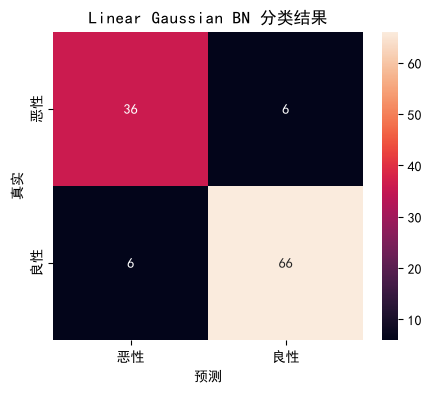

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(5,4))


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "恶性",
        "良性"
    ],
    yticklabels=[
        "恶性",
        "良性"
    ]
)


plt.xlabel("预测")
plt.ylabel("真实")

plt.title(
    "Linear Gaussian BN 分类结果"
)


plt.show()